In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/products.csv
/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/sales.csv
/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/warranty.csv
/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/stores.csv
/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/category.csv


In [2]:
df_products = pd.read_csv('/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/products.csv')
df_sales = pd.read_csv('/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/sales.csv')
df_warranty = pd.read_csv('/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/warranty.csv')
df_stores = pd.read_csv('/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/stores.csv')
df_category = pd.read_csv('/kaggle/input/datasets/amangarg08/apple-retail-sales-dataset/category.csv')

In [3]:
print(df_products.head(5))
print()
print()
print(df_sales.head(5))
print()
print()
print(df_warranty.head(5))
print()
print()
print(df_stores.head(5))
print()
print()
print(df_category.head(5))

  Product_ID         Product_Name Category_ID Launch_Date  Price
0        P-1              MacBook       CAT-1  2023-09-17   1149
1        P-2     MacBook Air (M1)       CAT-1  2023-11-11   1783
2        P-3     MacBook Air (M2)       CAT-1  2020-05-24   1588
3        P-4  MacBook Pro 13-inch       CAT-1  2021-01-17   1351
4        P-5  MacBook Pro 14-inch       CAT-1  2024-05-12    768


     sale_id   sale_date store_id product_id  quantity
0    YG-8782  16-06-2023    ST-10       P-38        10
1  QX-999001  13-04-2022    ST-63       P-48        10
2   JG-46890  05-07-2021    ST-26       P-79         5
3    XJ-1731  20-07-2022    ST-15       P-24         9
4   FG-95080  18-03-2022    ST-35       P-69         7


   claim_id  claim_date    sale_id repair_status
0  CL-58750  2024-01-30    YG-8782     Completed
1   CL-8874  2024-06-25  QX-999001       Pending
2  CL-14486  2024-08-13   JG-46890       Pending
3  CL-42187  2024-09-19    XJ-1731       Pending
4  CL-37590  2024-09-16   FG-95

In [4]:
print(df_products.isna().sum())
print()
print()

print(df_sales.isna().sum())
print()
print()

print(df_warranty.isna().sum())
print()
print()

print(df_stores.isna().sum())
print()
print()


print(df_category.isna().sum())
print()
print()

Product_ID      0
Product_Name    0
Category_ID     0
Launch_Date     0
Price           0
dtype: int64


sale_id       0
sale_date     0
store_id      0
product_id    0
quantity      0
dtype: int64


claim_id         0
claim_date       0
sale_id          0
repair_status    0
dtype: int64


Store_ID      0
Store_Name    0
City          0
Country       0
dtype: int64


category_id      0
category_name    0
dtype: int64




In [5]:
print(df_products.info())
print()
print()


print(df_sales.info())
print()
print()



print(df_warranty.info())
print()
print()




print(df_stores.info())
print()
print()



print(df_category.info())
print()
print()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_ID    89 non-null     object
 1   Product_Name  89 non-null     object
 2   Category_ID   89 non-null     object
 3   Launch_Date   89 non-null     object
 4   Price         89 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.6+ KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   sale_id     1040200 non-null  object
 1   sale_date   1040200 non-null  object
 2   store_id    1040200 non-null  object
 3   product_id  1040200 non-null  object
 4   quantity    1040200 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 39.7+ MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data co

In [6]:
df_products['Launch_Date'] = pd.to_datetime(df_products['Launch_Date'], errors='coerce')
df_products['Price'] = df_products['Price'].astype('float32')

df_sales['sale_date'] = pd.to_datetime( df_sales['sale_date'], format='%d-%m-%Y', errors='coerce' )
df_sales['quantity'] = df_sales['quantity'].astype('float32')


df_warranty['claim_date'] = pd.to_datetime( df_warranty['claim_date'], format='%Y-%m-%d', errors='coerce' )
df_warranty['repair_status'] = df_warranty['repair_status'].astype('category')

df_stores['City'] = df_stores['City'].astype('category')
df_stores['Country'] = df_stores['Country'].astype('category')

df_category['category_name'] = df_category['category_name'].astype('category')


In [7]:
for d in [df_sales, df_products, df_category, df_stores]:
    d.columns = d.columns.str.strip().str.lower()

In [8]:
# Unir tablas (joins)

df_sp = df_sales.merge(df_products, on="product_id", how="left")
df_spc = df_sp.merge(df_category, on="category_id", how="left")
df_final = df_spc.merge(df_stores, on="store_id", how="left")

In [9]:
w_agg = df_warranty.groupby('sale_id', as_index=False).agg(
    n_claims=('claim_id', 'count')
)

df_final = df_final.merge(w_agg, on='sale_id', how='left')
df_final['n_claims'] = df_final['n_claims'].fillna(0)


In [10]:
df_final['revenue'] = df_final['quantity'] * df_final['price']

In [11]:
df_final.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,category_id,launch_date,price,category_name,store_name,city,country,n_claims,revenue
0,YG-8782,2023-06-16,ST-10,P-38,10.0,iPhone 13 Pro,CAT-4,2021-03-22,308.0,Smartphone,Apple South Coast Plaza,Costa Mesa,United States,1.0,3080.0
1,QX-999001,2022-04-13,ST-63,P-48,10.0,Apple Watch Nike Edition,CAT-5,2020-06-24,884.0,Wearable,Apple Parque La Colina,Bogota,Colombia,1.0,8840.0
2,JG-46890,2021-07-05,ST-26,P-79,5.0,Magic Trackpad,CAT-10,2024-05-25,1242.0,Accessories,Apple Leidseplein,Amsterdam,Netherlands,1.0,6210.0
3,XJ-1731,2022-07-20,ST-15,P-24,9.0,iPad mini (6th Generation),CAT-3,2022-11-27,573.0,Tablet,Apple Downtown Brooklyn,Brooklyn,United States,1.0,5157.0
4,FG-95080,2022-03-18,ST-35,P-69,7.0,Apple TV+,CAT-8,2024-11-04,404.0,Subscription Service,Apple Shanghai IFC,Shanghai,China,1.0,2828.0


In [12]:
df_final.isna().sum()

sale_id          0
sale_date        0
store_id         0
product_id       0
quantity         0
product_name     0
category_id      0
launch_date      0
price            0
category_name    0
store_name       0
city             0
country          0
n_claims         0
revenue          0
dtype: int64

In [13]:
mask = (
    (df_final['quantity'] <= 0) |
    (df_final['price'] <= 0) |
    (df_final['revenue'] <= 0)
)

df_issues = df_final[mask]
df_issues.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,category_id,launch_date,price,category_name,store_name,city,country,n_claims,revenue


<Axes: >

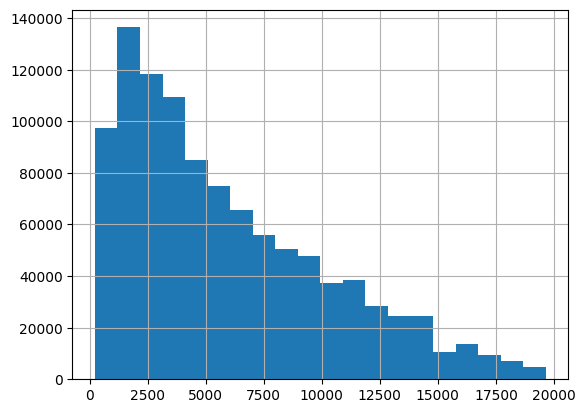

In [14]:
df_final['revenue'].hist(bins=20)

In [15]:
# Top tiendas por revenue
df_final['revenue'] = df_final['revenue'].astype('float64')
df_top=df_final.groupby('store_name')['revenue'].sum().sort_values(ascending=False).head(3)
df_top

store_name
Apple Chadstone         165220023.0
Apple Covent Garden     165176160.0
Apple The Dubai Mall    163741158.0
Name: revenue, dtype: float64

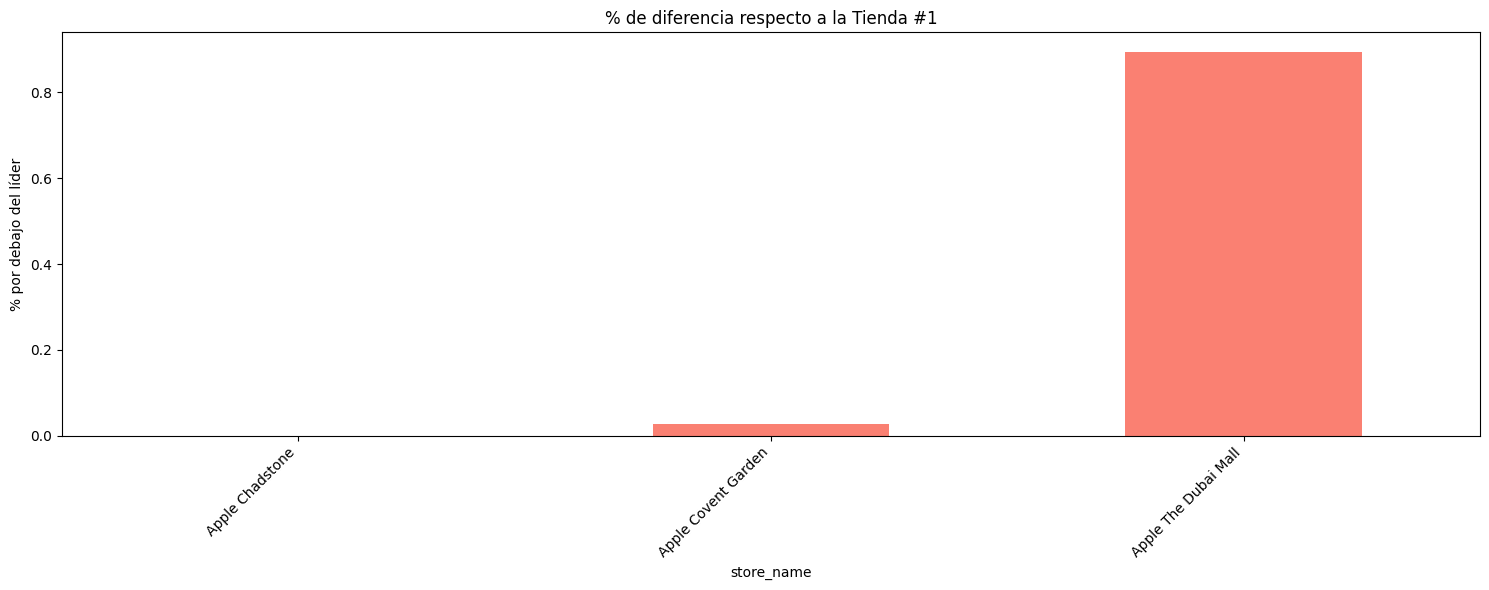

43863.0
1435002.0


In [16]:
import matplotlib.pyplot as plt
import numpy as np

diff_vs_top = (df_top.iloc[0] - df_top) / df_top.iloc[0] * 100

plt.figure(figsize=(15, 6))
diff_vs_top.plot(kind='bar', color=['green'] + ['salmon'] * (len(diff_vs_top)-1))
plt.title('% de diferencia respecto a la Tienda #1')
plt.ylabel('% por debajo del líder')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ¿Qué tan grande es la diferencia:
print(df_top.iloc[0]-df_top.iloc[1]) 
print(df_top.iloc[1]-df_top.iloc[2]) 

In [17]:
# cantidad vendida x ticket promedio
df_final.groupby('store_name')['revenue'].mean().sort_values(ascending=False).head(3)


store_name
Apple Yas Mall        6025.653383
Apple Union Square    5988.541196
Apple Dubai Mall      5985.830511
Name: revenue, dtype: float64

Apple Dubai Mall destaca como la tienda más completa, combinando alto volumen de ventas con un ticket promedio elevado, lo que la posiciona como el principal generador de ingresos. En contraste, tiendas como Apple Yas Mall muestran tickets altos pero menor volumen, lo que limita su contribución total al revenue.”

In [18]:
df_final.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,category_id,launch_date,price,category_name,store_name,city,country,n_claims,revenue
0,YG-8782,2023-06-16,ST-10,P-38,10.0,iPhone 13 Pro,CAT-4,2021-03-22,308.0,Smartphone,Apple South Coast Plaza,Costa Mesa,United States,1.0,3080.0
1,QX-999001,2022-04-13,ST-63,P-48,10.0,Apple Watch Nike Edition,CAT-5,2020-06-24,884.0,Wearable,Apple Parque La Colina,Bogota,Colombia,1.0,8840.0
2,JG-46890,2021-07-05,ST-26,P-79,5.0,Magic Trackpad,CAT-10,2024-05-25,1242.0,Accessories,Apple Leidseplein,Amsterdam,Netherlands,1.0,6210.0
3,XJ-1731,2022-07-20,ST-15,P-24,9.0,iPad mini (6th Generation),CAT-3,2022-11-27,573.0,Tablet,Apple Downtown Brooklyn,Brooklyn,United States,1.0,5157.0
4,FG-95080,2022-03-18,ST-35,P-69,7.0,Apple TV+,CAT-8,2024-11-04,404.0,Subscription Service,Apple Shanghai IFC,Shanghai,China,1.0,2828.0
